##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

### Chosen classes:

1. basketball
2. biking
3. diving


### 1. Environment Setup

In [52]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
!pip install opencv-python matplotlib tensorflow scikit-learn moviepy

In [54]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [55]:
seed_constant = 23

np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

### 2. Dataset Extraction

In [56]:
!apt-get install unrar

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [57]:
!mkdir -p /content/ucf11_data
!unrar x -o+ "/content/drive/MyDrive/ARTI560_ActionRecognition/UCF11_updated_mpg.rar" "/content/ucf11_data/"


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/drive/MyDrive/ARTI560_ActionRecognition/UCF11_updated_mpg.rar

Extracting  /content/ucf11_data/UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_01.mpg       0%  OK 
Extracting  /content/ucf11_data/UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_02.mpg       0%  OK 
Extracting  /content/ucf11_data/UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_03.mpg       0%  OK 
Extracting  /content/ucf11_data/UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_04.mpg       0%  OK 
Extracting  /content/ucf11_data/UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_05.mpg       0%  OK 
Extracting  /content/ucf11_data/UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_06.mpg       0%  OK 
Extracting  /content/ucf11_data/UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_07.mpg       0%  OK 
Ext

### 3. Preprocessing The Dataset

In [58]:
dataset_root = '/content/ucf11_data/UCF11_updated_mpg'
classes_list = ['basketball', 'biking', 'diving']

image_height, image_width = 64, 64
max_frames_per_class = 800
seed_constant = 23

np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

print("Dataset root:", dataset_root)
print("Chosen classes:", classes_list)

Dataset root: /content/ucf11_data/UCF11_updated_mpg
Chosen classes: ['basketball', 'biking', 'diving']


In [59]:
def get_video_files_for_class(class_path):
    video_files = []

    for root, dirs, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith('.mpg'):
                video_files.append(os.path.join(root, file))

    return video_files

In [60]:
for class_name in classes_list:
    class_path = os.path.join(dataset_root, class_name)
    video_files = get_video_files_for_class(class_path)
    print(f"{class_name}: {len(video_files)} videos")
    print(video_files[:3])
    print()

basketball: 141 videos
['/content/ucf11_data/UCF11_updated_mpg/basketball/v_shooting_08/v_shooting_08_01.mpg', '/content/ucf11_data/UCF11_updated_mpg/basketball/v_shooting_08/v_shooting_08_04.mpg', '/content/ucf11_data/UCF11_updated_mpg/basketball/v_shooting_08/v_shooting_08_02.mpg']

biking: 145 videos
['/content/ucf11_data/UCF11_updated_mpg/biking/v_biking_02/v_biking_02_02.mpg', '/content/ucf11_data/UCF11_updated_mpg/biking/v_biking_02/v_biking_02_07.mpg', '/content/ucf11_data/UCF11_updated_mpg/biking/v_biking_02/v_biking_02_05.mpg']

diving: 156 videos
['/content/ucf11_data/UCF11_updated_mpg/diving/v_diving_10/v_diving_10_07.mpg', '/content/ucf11_data/UCF11_updated_mpg/diving/v_diving_10/v_diving_10_04.mpg', '/content/ucf11_data/UCF11_updated_mpg/diving/v_diving_10/v_diving_10_03.mpg']



In [61]:
def frames_extraction(video_path):
    frames_list = []

    video_reader = cv2.VideoCapture(video_path)

    while True:
        success, frame = video_reader.read()
        if not success:
            break

        resized_frame = cv2.resize(frame, (image_width, image_height))
        normalized_frame = resized_frame / 255.0

        frames_list.append(normalized_frame)

    video_reader.release()
    return frames_list

In [62]:
def create_dataset():
    features = []
    labels = []

    for class_index, class_name in enumerate(classes_list):
        print(f'Processing class: {class_name}')

        class_path = os.path.join(dataset_root, class_name)
        video_files = get_video_files_for_class(class_path)

        temp_features = []

        for video_file in video_files:
            frames = frames_extraction(video_file)
            temp_features.extend(frames)

        print(f"Total frames found for {class_name}: {len(temp_features)}")

        if len(temp_features) > max_frames_per_class:
            selected_frames = random.sample(temp_features, max_frames_per_class)
        else:
            selected_frames = temp_features

        features.extend(selected_frames)
        labels.extend([class_index] * len(selected_frames))

        print(f"Frames used for {class_name}: {len(selected_frames)}")
        print()

    features = np.asarray(features)
    labels = np.array(labels)

    return features, labels

In [63]:
features, labels = create_dataset()

print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

Processing class: basketball
Total frames found for basketball: 19230
Frames used for basketball: 800

Processing class: biking
Total frames found for biking: 32863
Frames used for biking: 800

Processing class: diving
Total frames found for diving: 26740
Frames used for diving: 800

Features shape: (2400, 64, 64, 3)
Labels shape: (2400,)


In [64]:
one_hot_encoded_labels = to_categorical(labels)
print("One-hot labels shape:", one_hot_encoded_labels.shape)

One-hot labels shape: (2400, 3)


In [65]:
features_train, features_test, labels_train, labels_test = train_test_split(
    features,
    one_hot_encoded_labels,
    test_size=0.2,
    shuffle=True,
    random_state=seed_constant
)

print("Training features shape:", features_train.shape)
print("Testing features shape:", features_test.shape)
print("Training labels shape:", labels_train.shape)
print("Testing labels shape:", labels_test.shape)

Training features shape: (1920, 64, 64, 3)
Testing features shape: (480, 64, 64, 3)
Training labels shape: (1920, 3)
Testing labels shape: (480, 3)


### 4. Creating & Training The Model

In [73]:
def create_model():
    model = Sequential()

    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(image_height, image_width, 3)))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    model.add(GlobalAveragePooling2D())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(model_output_size, activation='softmax'))

    model.summary()
    return model

model = create_model()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,355 (110.76 KB)

 Trainable params: 28,227 (110.26 KB)

 Non-trainable params: 128 (512.00 B)

In [74]:
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=4,
    mode='min',
    restore_best_weights=True
)

model.compile(
    loss='categorical_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)

model_training_history = model.fit(
    x=features_train,
    y=labels_train,
    epochs=12,
    batch_size=8,
    shuffle=True,
    validation_split=0.2,
    callbacks=[early_stopping_callback]
)

Epoch 1/12
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6035 - loss: 0.8526 - val_accuracy: 0.6094 - val_loss: 0.9335
Epoch 2/12
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7057 - loss: 0.6676 - val_accuracy: 0.7760 - val_loss: 0.7129
Epoch 3/12
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7702 - loss: 0.5370 - val_accuracy: 0.8021 - val_loss: 0.4874
Epoch 4/12
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8242 - loss: 0.4438 - val_accuracy: 0.8099 - val_loss: 0.4728
Epoch 5/12
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8607 - loss: 0.3797 - val_accuracy: 0.8568 - val_loss: 0.4269
Epoch 6/12
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8815 - loss: 0.3325 - val_accuracy: 0.8932 - val_loss: 0.2811
Epoch 7/12
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9049 - loss: 0.2919 - val_accuracy: 0.7812 - val_loss: 0.6118
Epoch 8/12
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9102 - loss: 0.2591 - val_accuracy: 0.

In [75]:
model_evaluation_history = model.evaluate(features_test, labels_test)
print("Test loss and accuracy:", model_evaluation_history)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9500 - loss: 0.1504   
Test loss and accuracy: [0.1504388153553009, 0.949999988079071]


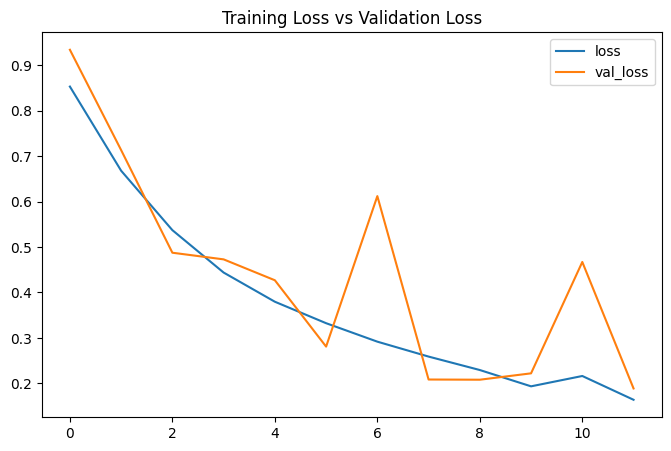

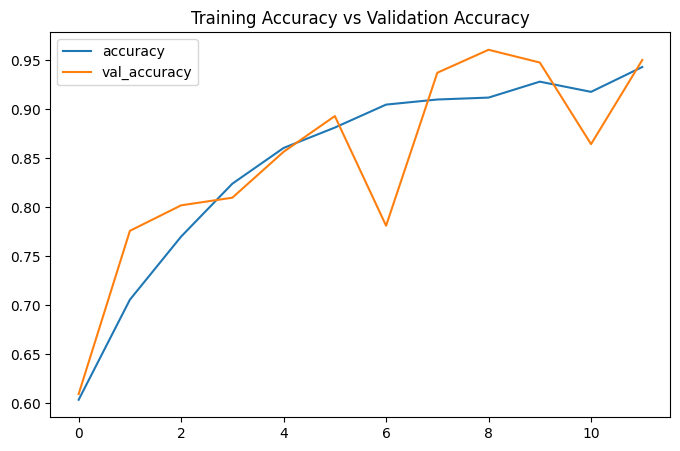

In [76]:
def plot_metric(metric_name_1, metric_name_2, plot_name):
    metric_value_1 = model_training_history.history[metric_name_1]
    metric_value_2 = model_training_history.history[metric_name_2]

    epochs = range(len(metric_value_1))

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, metric_value_1, label=metric_name_1)
    plt.plot(epochs, metric_value_2, label=metric_name_2)
    plt.title(plot_name)
    plt.legend()
    plt.show()

plot_metric('loss', 'val_loss', 'Training Loss vs Validation Loss')
plot_metric('accuracy', 'val_accuracy', 'Training Accuracy vs Validation Accuracy')

In [77]:
student_name = "Sara_Alzahrani"
save_path = f"/content/drive/MyDrive/ARTI560_ActionRecognition/{student_name}_ucf11_model.h5"

model.save(save_path)

print(f"Model saved as {save_path}")

Model saved as /content/drive/MyDrive/ARTI560_ActionRecognition/Sara_Alzahrani_ucf11_model.h5


### 5. Validate on 3 YouTube videos

In [78]:
def make_average_predictions(video_file_path, predictions_frames_count=20):
    predicted_labels_probabilities_np = np.zeros((predictions_frames_count, model_output_size), dtype=float)

    video_reader = cv2.VideoCapture(video_file_path)
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))

    if video_frames_count == 0:
        video_reader.release()
        return None, None

    skip_frames_window = max(video_frames_count // predictions_frames_count, 1)

    for frame_counter in range(predictions_frames_count):
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)
        success, frame = video_reader.read()

        if not success:
            continue

        resized_frame = cv2.resize(frame, (image_width, image_height))
        normalized_frame = resized_frame / 255.0

        predicted_labels_probabilities = model.predict(
            np.expand_dims(normalized_frame, axis=0),
            verbose=0
        )[0]

        predicted_labels_probabilities_np[frame_counter] = predicted_labels_probabilities

    video_reader.release()

    average_probabilities = predicted_labels_probabilities_np.mean(axis=0)
    predicted_label = np.argmax(average_probabilities)
    predicted_class_name = classes_list[predicted_label]

    return predicted_class_name, average_probabilities

In [79]:
def predict_video(video_path):
    predicted_class_name, average_probabilities = make_average_predictions(video_path, predictions_frames_count=20)

    if predicted_class_name is None:
        print("Could not read video.")
        return

    print("Video:", video_path)
    print("Predicted class:", predicted_class_name)
    print("Class probabilities:")

    for class_name, prob in zip(classes_list, average_probabilities):
        print(f"  {class_name}: {prob:.4f}")

In [85]:
test_videos_folder = "/content/drive/MyDrive/ARTI560_ActionRecognition/test_videos"

basketball_video = os.path.join(test_videos_folder, "basketball_test.mp4")
biking_video = os.path.join(test_videos_folder, "biking_test.mp4")
diving_video = os.path.join(test_videos_folder, "diving_test.mp4")

predict_video(basketball_video)
print()

predict_video(biking_video)
print()

predict_video(diving_video)

Video: /content/drive/MyDrive/ARTI560_ActionRecognition/test_videos/basketball_test.mp4
Predicted class: basketball
Class probabilities:
  basketball: 0.9977
  biking: 0.0001
  diving: 0.0021

Video: /content/drive/MyDrive/ARTI560_ActionRecognition/test_videos/biking_test.mp4
Predicted class: biking
Class probabilities:
  basketball: 0.1938
  biking: 0.7655
  diving: 0.0407

Video: /content/drive/MyDrive/ARTI560_ActionRecognition/test_videos/diving_test.mp4
Predicted class: diving
Class probabilities:
  basketball: 0.0000
  biking: 0.0007
  diving: 0.9992
